# Static Optimisation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from src.static_optim import (
    StaticPortfolioOptimizer,
    EfficientFrontierPlotter,
    NAVPlotter,
    PhiUtilityPlotter,
    RiskCloudPlotter
)

# Load data
returns = pd.read_csv("data/cleaned/monthly_returns.csv", index_col=0).astype(float)
returns.index = pd.to_datetime(returns.index)

mu_G = pd.read_csv("parameters/mu_latent.csv", index_col=0).to_numpy().flatten()
Sigma_G = pd.read_csv("parameters/Sigma_latent.csv", index_col=0).to_numpy()

phi = 0.7
rf = (1 + 0.04)**(1/12) - 1
mu_T_annual = 0.06
mu_T = (1 + mu_T_annual)**(1/12) - 1

# optimiser
opt = StaticPortfolioOptimizer(mu_G, Sigma_G, phi, rf)

w_growth, active = opt.optimise_growth_bucket(r_target=mu_T, L=-10*np.ones(len(mu_G)), U=0.3*np.ones(len(mu_G)))
w_full = opt.combine_with_cash(w_growth)
print(w_full)

[0.3        0.15894194 0.09613874 0.01564681 0.00927251 0.21
 0.21      ]


/Users/kennyyu/miniconda3/envs/fmat3888/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


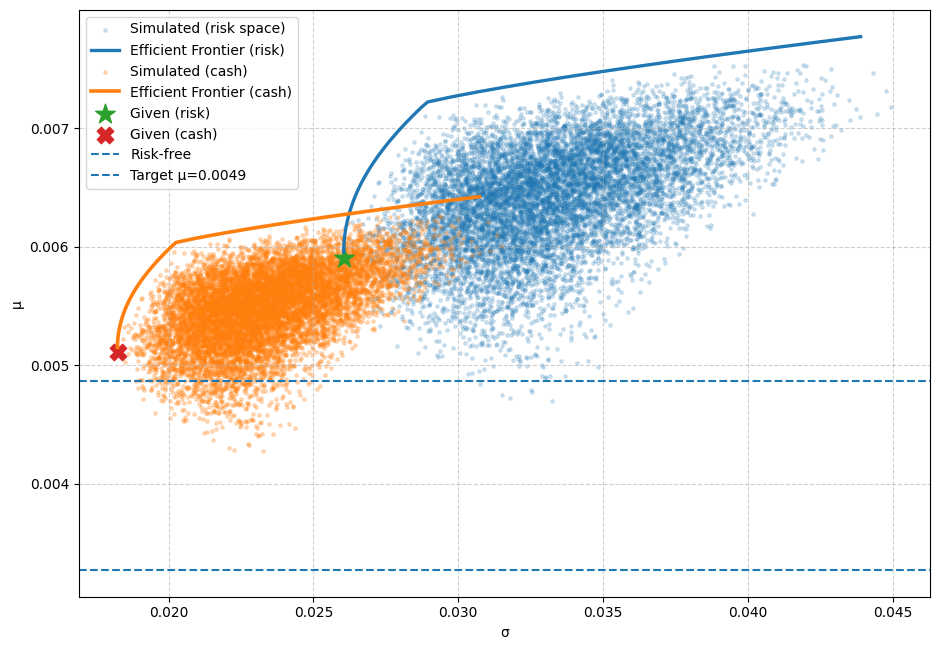

In [4]:
EfficientFrontierPlotter.plot_with_cash_only(mu_G, Sigma_G, phi, rf, mu_T, w=w_growth)

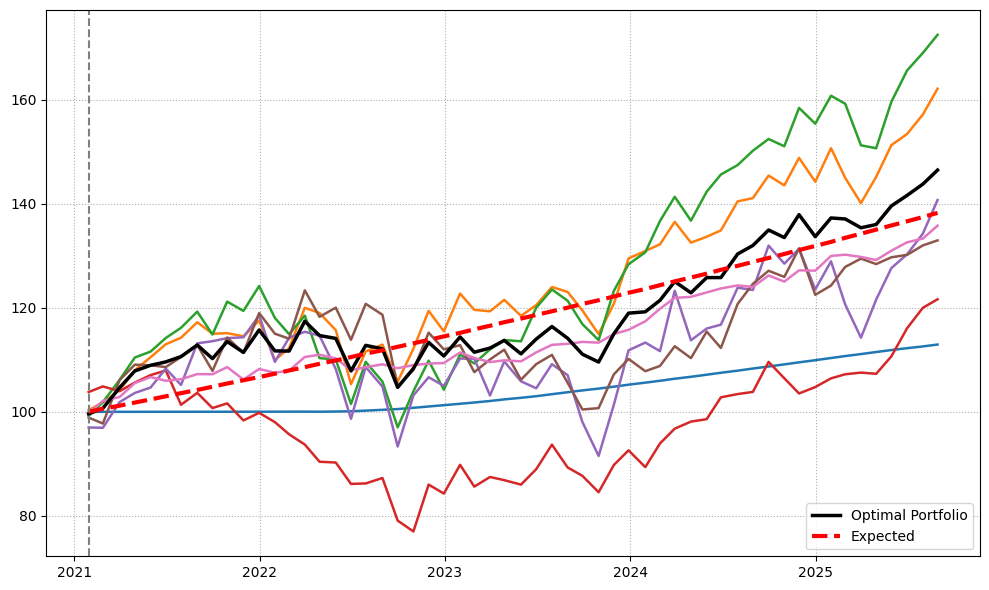

In [5]:
NAVPlotter.plot_after_cut(returns, mu_G, w_growth, rf)

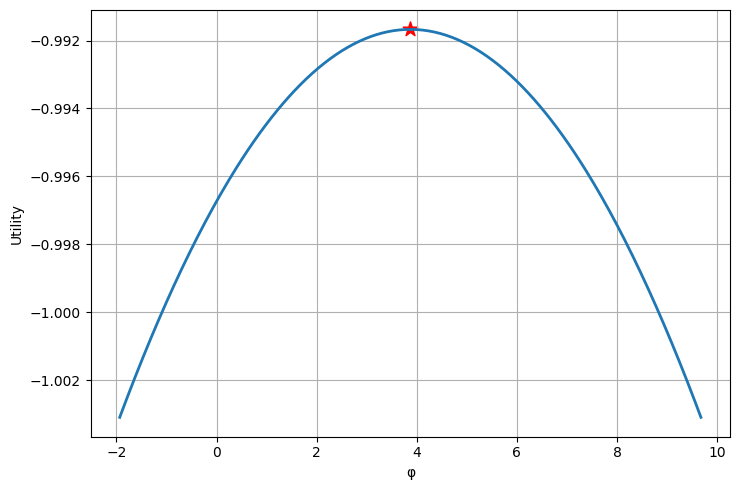

In [6]:
PhiUtilityPlotter.plot_phi_Z(mu_G, Sigma_G, w_growth, rf)

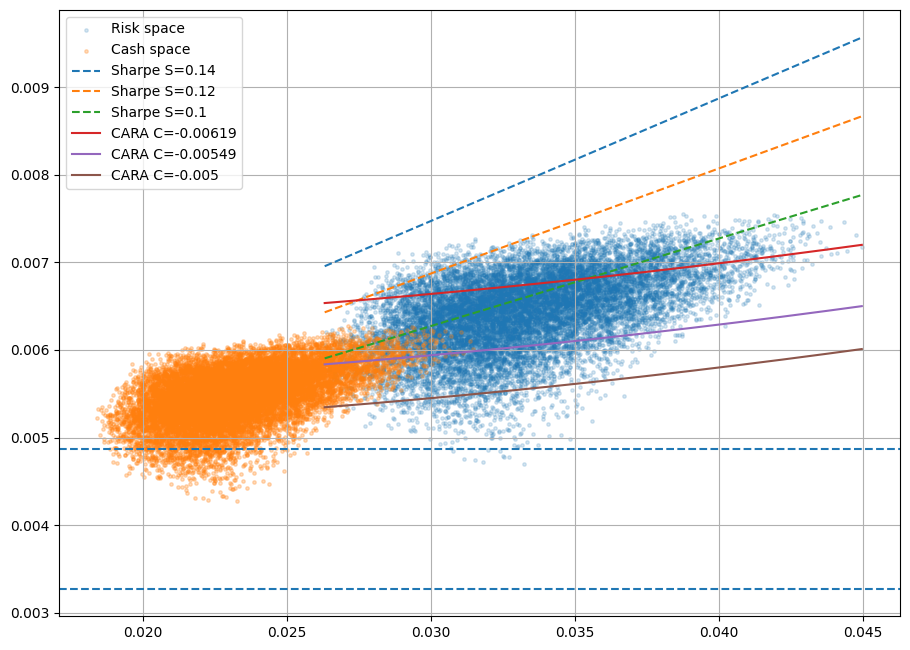

In [7]:
RiskCloudPlotter.plot(mu_G, Sigma_G, phi, rf, mu_T)